# Даалгавар 2: Pandas-ийн давтлага

Энэ даалгаварын 1-р хэсэг нь өгөгдөл боловсруулах (data-wrangling) зориулалттай Python-ийн хамгийн түгээмэл сангуудын нэг болох [Pandas](https://pandas.pydata.org/docs/)-ийг давтан сэргээхэд чиглэнэ. Машин сургалтын судлаач, инженер бүрийн багаж хэрэгслийн үндсэн бүрэлдэхүүн бөгөөд улирлын турш та үүнийг өргөнөөр ашиглана.

IMDb-ийн кино өгөгдөл дээр ажиллах өнөөдрийн дасгалд шаардлагатай сангуудыг эхлээд ачаална. Бид өгөгдлийг интернетээс татан уншихдаа `read_csv` функцийг ашиглана. Мөн энэхүү функцээр локал хадгалсан файлыг унших боломжтой.

*ТАЙЛБАР: Нүднүүдийг (cells) дарааллаар нь ажиллуулаагүй тохиолдолд, код зөв байсан ч гаралт зөв биш байж болно. Эргэлзэж байвал бүх нүдийг нэг дор ажиллуулж болно — хэдхэн секунд л зарцуулна.*

In [50]:
import os, random, numpy as np
SEED = 189

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

In [30]:
import pandas as pd
import plotly.express as px

# Load the title_basics dataset from IMDb
title_basics  = pd.read_csv(
    "https://datasets.imdbws.com/title.basics.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N", nrows=500000
)
# Load the title_ratings dataset from IMDb
title_ratings = pd.read_csv(
    "https://datasets.imdbws.com/title.ratings.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N", nrows=500000
)

# Sort both dataframes by 'tconst' and reset the index
title_basics  = title_basics.sort_values("tconst", kind="mergesort").reset_index(drop=True)
title_ratings = title_ratings.sort_values("tconst", kind="mergesort").reset_index(drop=True)

## 1-р хэсэг: Өгөгдөлтэй танилцах ба өгөгдөл цэвэрлэгээ

Эхлээд `title_basics` `DataFrame`-ийг шинжилж үзье.

### Асуулт 1.1

`title_basics` `DataFrame` хэдэн баганатай вэ?

`startYear` баганын өгөгдлийн төрөл (data type) юу вэ? Энэ нь утга агуулгын хувьд зөв/логик сонголт мөн үү?

In [31]:

# YOUR CODE H
df = pd.DataFrame(title_basics)
numb_cols = df.shape[1]
print(numb_cols)

print(df['startYear'].dtype)

9
float64


### Асуулт 1.2

`title_basics` `DataFrame`-ийн `primaryTitle` баганын **101 дэх мөрөнд** ямар утга байна вэ?

*САНАМЖ: `DataFrame` нь 0-оос эхэлсэн индексжилт (0-indexing) ашигладаг.*

In [32]:
print(df['primaryTitle'].iloc[100])
# YOUR CODE HERE


The Beach at Villiers in a Gale


### Асуулт 1.3

`title_basics` `DataFrame`-ийн эхний 3 мөр болон сүүлийн 6 мөрийг нэгтгэн **нэг** `DataFrame` болгон харуул.

In [33]:

# YOUR CODE HERE
first3 = df.head(3)
last6 = df.tail(6)
cmb_df = pd.merge(first3, last6, how='outer')
print(cmb_df)


      tconst  titleType                     primaryTitle  \
0  tt0000001      short                       Carmencita   
1  tt0000002      short           Le clown et ses chiens   
2  tt0000003      short                     Poor Pierrot   
3  tt0520723  tvEpisode  Episode dated 22 September 2003   
4  tt0520724  tvEpisode  Episode dated 29 September 2003   
5  tt0520725  tvEpisode     Episode dated 6 October 2003   
6  tt0520726  tvEpisode    Episode dated 13 October 2003   
7  tt0520727  tvEpisode    Episode dated 20 October 2003   
8  tt0520728  tvEpisode    Episode dated 27 October 2003   

                     originalTitle  isAdult  startYear  endYear  \
0                       Carmencita        0     1894.0      NaN   
1           Le clown et ses chiens        0     1892.0      NaN   
2                   Pauvre Pierrot        0     1892.0      NaN   
3  Episode dated 22 September 2003        0     2003.0      NaN   
4  Episode dated 29 September 2003        0     2003.0      NaN 

### Асуулт 1.4

`title_basics` `DataFrame`-д хэдэн өвөрмөц (`unique`) `titleTypes` байна вэ? Аль нь хамгийн түгээмэл вэ?

In [34]:

# YOUR CODE HERE
type_counts = df['titleType'].value_counts()
first_type = type_counts.index[0]
print(type_counts.count())
print(first_type)


10
movie


Одоо `DataFrame` дээр түгээмэл хэрэглэгддэг өөрчлөлтүүдийг дадлагажъя.

### Асуулт 1.5

`title_basics` `DataFrame`-ээс `originalTitle` болон `endYear` багануудыг устга. Эдгээр багана `title_basics`-оос **байнгын** устгагдсан байх ёстой.

In [35]:

# YOUR CODE HERE
title_basics.drop(columns=['originalTitle', 'endYear'], inplace=True)

title_basics.head()

,tconst,titleType,primaryTitle,isAdult,startYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,0,1894.0,1.0,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,0,1892.0,5.0,"Animation,Short"
2,tt0000003,short,Poor Pierrot,0,1892.0,5.0,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,0,1892.0,12.0,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,0,1893.0,1.0,Short


### Асуулт 1.6

`title_basics` `DataFrame`-д `primaryTitle` баганыг `title`, `startYear` баганыг `year` гэж нэрийг нь өөрчил. Өөрчлөлт нь `title_basics` дээр **байнгын** хадгалагдсан эсэхийг баталгаажуул.

In [36]:

title_basics = title_basics.rename(columns={'primaryTitle' : 'title', 'startYear' : 'year'})

title_basics.head()

,tconst,titleType,title,isAdult,year,runtimeMinutes,genres
0,tt0000001,short,Carmencita,0,1894.0,1.0,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,0,1892.0,5.0,"Animation,Short"
2,tt0000003,short,Poor Pierrot,0,1892.0,5.0,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,0,1892.0,12.0,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,0,1893.0,1.0,Short


### Асуулт 1.7

Машин сургалтын ихэнх өгөгдөл боловсруулах урсгал (pipeline)-ын чухал алхам бол дутуу эсвэл гэмтсэн өгөгдөлтэй ажиллах явдал юм. Ихэвчлэн ийм дутуу утгуудыг `NaN` (not a number) гэж тэмдэглэдэг.

Зарим нөхцөлд бид тухайн мөрийг бүхэлд нь хаяхын оронд, дутуу шинж (feature)-ийн утгыг **таамаглан нөхөх** (imputation) шаардлагатай болдог. Ийм таамаглал хийх энгийн ямар аргууд байж болох вэ?

Статистик дундаж ашиглаж болно. Тоон утгат өгөгдлийн хувьд тухайн баганын бүх утгуудын дундаж.

### Асуулт 1.8

`title_basics` `DataFrame`-ээс `runtimeMinutes` эсвэл `year` нь `NaN` байгаа бүх мөрийг устга.

In [37]:

initial_length = title_basics.shape[0]

title_basics = title_basics.dropna(subset=['year'])
# title_basics = title_basics.dropna(subset=['runtimeMinutes']) year runtime hoyulangiin nan ustsan

final_length = title_basics.shape[0]

print(f"{initial_length - final_length} rows removed from dataframe")


1027 rows removed from dataframe


### Асуулт 1.9

`title_basics` `DataFrame`-ийн `year` баганын өгөгдлийн төрлийг илүү зохистой төрөл болгон өөрчил. Дараа нь өөрчлөлт **байнгын** хэрэгжсэн эсэхийг шалгаж баталгаажуул.

In [38]:

# YOUR CODE HERE
# print(title_basics['year'].describe())
print(title_basics.info())
print(title_basics.dtypes)
print(title_basics['year'].isnull().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 498973 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          498973 non-null  object 
 1   titleType       498973 non-null  object 
 2   title           498973 non-null  object 
 3   isAdult         498973 non-null  int64  
 4   year            498973 non-null  float64
 5   runtimeMinutes  355276 non-null  float64
 6   genres          452356 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 30.5+ MB
None
tconst             object
titleType          object
title              object
isAdult             int64
year              float64
runtimeMinutes    float64
genres             object
dtype: object
0


Одоо илүү суурь шүүлтүүр (filter) ба эрэмбэлэлт (sort)-ийг дадлагажъя.

### Асуулт 1.10

`title_basics` `DataFrame`-ээс 1954 онд гарсан бүрэн хэмжээний кинонуудыг (`titleType == "movie"`) шүүн ав. Үр дүнг шинэ `DataFrame` болгон `feature_films_1954` нэрээр хадгал.

In [39]:
# YOUR CODE HERE
feature_films_1954 = title_basics[(title_basics['year'] == 1954 ) & (title_basics['titleType'] == "movie")]
feature_films_1954.head()

,tconst,titleType,title,isAdult,year,runtimeMinutes,genres
35844,tt0036493,movie,Mystery of the Black Jungle,0,1954.0,80.0,"Action,Adventure,Mystery"
36914,tt0037585,movie,Knights of the Queen,0,1954.0,79.0,Adventure
37343,tt0038020,movie,Relato policíaco,0,1954.0,75.0,Crime
37410,tt0038089,movie,Siluri umani,0,1954.0,87.0,"Drama,War"
37558,tt0038240,movie,Das Licht der Liebe,0,1954.0,95.0,Drama


### Асуулт 1.11

1954 оны бүрэн хэмжээний кинонуудаас хамгийн урт үргэлжлэх хугацаатай (runtime) кино аль нь вэ? Түүний `title` болон `runtimeMinutes`-ийг `feature_films_1954`-өөс ялган авч `DataFrame` хэлбэрээр буцаа.

In [40]:
# YOUR CODE HERE
sorted_films_1954 = feature_films_1954.sort_values(by='runtimeMinutes', ascending=False)
r = sorted_films_1954[['title', 'runtimeMinutes']]
r.head(1)


,title,runtimeMinutes
46203,Gunfighters of the Northwest,315.0


## 2-р хэсэг: Нарийн өөрчлөлтүүд, агрегаци, нэгтгэл (merge), зураглал

Эхлээд `title_basics` `DataFrame`-ийг өөрчилж, нэг мөр бүрт **нэг** жанр (genre) таарах байдлаар олон жанртай мөрүүдийг хуулбарлан задлана. Энэ хувиргалтад [`df.explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html) хэрэгтэй.

In [41]:
# Split the genres string into a list of genres
title_basics['genres'] = title_basics['genres'].str.split(',')
# Explode the list of genres into separate rows
title_basics = title_basics.explode('genres')

title_basics.head()

,tconst,titleType,title,isAdult,year,runtimeMinutes,genres
0,tt0000001,short,Carmencita,0,1894.0,1.0,Documentary
0,tt0000001,short,Carmencita,0,1894.0,1.0,Short
1,tt0000002,short,Le clown et ses chiens,0,1892.0,5.0,Animation
1,tt0000002,short,Le clown et ses chiens,0,1892.0,5.0,Short
2,tt0000003,short,Poor Pierrot,0,1892.0,5.0,Animation


### Асуулт 2.1

`title_basics` `DataFrame`-ийн жанр бүрийн хувьд 1960 оноос хойш гарсан бүрэн хэмжээний кинонуудын дундаж үргэлжлэх хугацааг (mean runtime) тооц.

Дундаж нь хамгийн урт 5 жанрыг харуул.

In [42]:

# YOUR CODE HERE
sorted_films_1960 = title_basics[(title_basics['year'] >= 1960) & (title_basics['titleType'] == 'movie')]
mean_of_1960 = sorted_films_1960.groupby('genres')['runtimeMinutes'].mean()
mean_of_1960.head()


genres
Action       101.723487
Adult         75.552707
Adventure     95.891793
Animation     81.544728
Biography    103.668018
Name: runtimeMinutes, dtype: float64

### Асуулт 2.2

`title_ratings` `DataFrame`-ийг `title_basics` `DataFrame`-тэй `tconst` баганаар нь холбон нэгтгэ (join). `title_basics`-д байгаа боловч `title_ratings`-д байхгүй гарчгууд (titles) хэд байна вэ? Нэгтгэсэн `DataFrame`-ийг `merged_df` гэж хадгал.

**САНАМЖ:** Жанрыг задласан (split/explode) тул “гарчгийн тоо” нь “мөрийн тоо”-той тэнцүү биш байж болно.

In [43]:
n_titles_basics = title_basics['tconst'].nunique()

merged_df = pd.merge(title_basics, title_ratings, on='tconst')
print(merged_df.head())

n_titles_merged = merged_df['tconst'].nunique()

print(f"\nNumber of titles in basics but not in ratings: {n_titles_basics - n_titles_merged}")

      tconst titleType                   title  isAdult    year  \
0  tt0000001     short              Carmencita        0  1894.0   
1  tt0000001     short              Carmencita        0  1894.0   
2  tt0000002     short  Le clown et ses chiens        0  1892.0   
3  tt0000002     short  Le clown et ses chiens        0  1892.0   
4  tt0000003     short            Poor Pierrot        0  1892.0   

   runtimeMinutes       genres  averageRating  numVotes  
0             1.0  Documentary            5.7      2193  
1             1.0        Short            5.7      2193  
2             5.0    Animation            5.5       309  
3             5.0        Short            5.5       309  
4             5.0    Animation            6.5      2297  

Number of titles in basics but not in ratings: 215430


### Асуулт 2.3

`merged_df` `DataFrame`-ийг ашиглан plotly express-ээр `runtimeMinutes` ба `numVotes`-ын хоорондын хамаарлыг харуулсан интерактив тархалтын график (interactive scatter plot) байгуул.

Цэгүүдийг киноны `year`-аар өнгөөр ялга, гарчиг болон тэнхлэгийн (axis) шошгыг нэм. Мөн өгөгдлийн цэг дээр хулганаа байрлуулахад киноны нэр (title) харагддаг байхаар тохируул.

**ТАЙЛБАР:** Дүрслэлийг ойлгомжтой болгохын тулд 2000 киноны санамсаргүй түүврийг ашиглана. Тиймээс таны дуртай зарим кино энэ графикт харагдахгүй байж болно. Санамсаргүй сонголтын (random state) тохиргоог өөрчлөхгүй байх нь дараагийн асуултуудын үр дүнг адил байлгахад чухал.

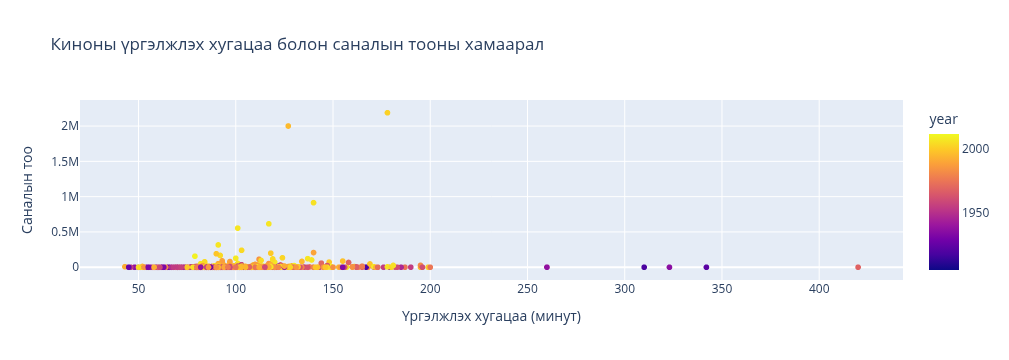

In [49]:
sampled_df = merged_df[merged_df['titleType'] == 'movie'].sample(n=2000, random_state=SEED)
import plotly.express as px
fig = px.scatter(
    sampled_df, 
    x='runtimeMinutes', 
    y='numVotes',
    color='year',         
    hover_name='title',
    title='Киноны үргэлжлэх хугацаа болон саналын тооны хамаарал',
    labels={'runtimeMinutes': 'Үргэлжлэх хугацаа (минут)', 'numVotes': 'Саналын тоо'}
)

fig.show()


### Асуулт 2.4

Дээрх графикаас ажиглагдах хандлага (trend)-уудыг тайлбарла.

diilenh kinonuud tsuun sanal avsan. tootoi heden kinonuudiin sanaliin too ih baigaag harj bolno

### Асуулт 2.5

Графикт:
- Хамгийн олон санал авсан (most votes) хоёр кино
- Хамгийн урт үргэлжлэх хугацаатай (longest runtime) кино

тус бүр аль нь вэ? Тэд хэзээ нээлтээ хийсэн бэ?

hamgiin olon sanal avsan : The Shawshank redemption, Batman begins.
hamgiin urt urgeljleh kino: A Retrospection of Leningrad

# 3-р хэсэг: Төгс киног олох нь

Aakarsh зунжин “doomscroll” хийсээр байгаад анхаарал төвлөрөл нь үнэхээр мууджээ. Өнөө орой үзэх кино сонгохдоо хэт урт байвал уйдахаас болгоомжилж байна. Тиймээс “Brainrot Score (BRS)” гэсэн үзүүлэлт зохиож, төгс киногоо олохоор шийдэв:

$$BRS = \frac{\text{averageRating}}{\sqrt{\text{runtimeMinutes}}}$$

Мөн дараах нөхцлүүд заавал биелэх ёстой:
- Гарчиг нь *movie* төрөлтэй, 1980 оноос хойш бүтээгдсэн байх.
- Дор хаяж 10000 саналтай (votes) байх.
- `History`, `Thriller`, эсвэл `Comedy` жанрын аль нэгэнд хамаарах.

Aakarsh-д туслаад, түүний сонирхсон жанр бүрээр BRS хамгийн өндөр **3** киног олж өгч чадах уу?

In [45]:
import pandas as pd
sort_for_akashi = merged_df[
    ((merged_df['genres'] == 'History') |
    (merged_df['genres'] == 'Thriller') |
    (merged_df['genres'] == 'Comedy'))&
    (merged_df['numVotes'] >= 10000) &
    (merged_df['titleType'] == 'movie') &
    (merged_df['year'] >= 1980)
    ].copy()
sort_for_akashi['BRS'] = sort_for_akashi['averageRating'] / sort_for_akashi['runtimeMinutes'] ** 0.5

In [46]:
comedy_3 = sort_for_akashi[sort_for_akashi['genres'] == 'Comedy'].sort_values(by='BRS', ascending=False)
thriller_3 = sort_for_akashi[sort_for_akashi['genres'] == 'Thriller'].sort_values(by='BRS', ascending=False)
history_3 = sort_for_akashi[sort_for_akashi['genres'] == 'History'].sort_values(by='BRS', ascending=False)

pd.concat([comedy_3.head(3), thriller_3.head(3), history_3.head(3)])

,tconst,titleType,title,isAdult,year,runtimeMinutes,genres,averageRating,numVotes,BRS
109206,tt0076276,movie,Who's Singin' Over There?,0,1980.0,86.0,Comedy,8.7,17821,0.938145
171017,tt0114709,movie,Toy Story,0,1995.0,81.0,Comedy,8.3,1163867,0.922222
122205,tt0084302,movie,The Marathon Family,0,1982.0,92.0,Comedy,8.8,18093,0.917463
215073,tt0154506,movie,Following,0,1998.0,69.0,Thriller,7.4,109478,0.890855
190750,tt0130827,movie,Run Lola Run,0,1998.0,80.0,Thriller,7.6,217079,0.849706
156301,tt0105236,movie,Reservoir Dogs,0,1992.0,99.0,Thriller,8.3,1163435,0.834181
452522,tt0436971,movie,Why We Fight,0,2005.0,98.0,History,8.0,10462,0.808122
174353,tt0116860,movie,"Pretty Village, Pretty Flame",0,1996.0,115.0,History,8.6,18897,0.801954
360063,tt0317910,movie,The Fog of War,0,2003.0,107.0,History,8.0,26094,0.773389
